In [2]:
import pandas as pd
import numpy as np
import glob
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

def load_and_preprocess(data):

    # 1. Lấy danh sách file và gộp dữ liệu
    all_files = glob.glob(data + "/*.csv")
    df_list = []
    
    for filename in all_files:
        print(f"Đang đọc file: {filename}")
        df = pd.read_csv(filename)
        
        # 2. Làm sạch tên cột ngay khi đọc (Tránh lỗi khoảng trắng)
        df.columns = df.columns.str.strip()
        
        # 3. Tối ưu bộ nhớ (Downcast) - Bỏ qua cột nhãn
        for col in df.columns:
            if col != 'Label':
                if df[col].dtype == 'float64':
                    df[col] = pd.to_numeric(df[col], downcast='float')
                elif df[col].dtype == 'int64':
                    df[col] = pd.to_numeric(df[col], downcast='integer')
        
        df_list.append(df)
    
    return pd.concat(df_list, axis=0, ignore_index=True)

def clean_data(df):

    # 1. Xử lý giá trị vô hạn (Inf) thành NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # 2. Xử lý NaN bằng Median thay vì drop
    # Chỉ tính median cho các cột số
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # 3. Xóa các dòng trùng lặp và các cột có phương sai bằng 0 (Zero variance)
    df.drop_duplicates(inplace=True)
    
    # Bảo vệ các cột quan trọng không bị xóa do variance
    critical_cols = ['Label', 'Protocol', 'Destination Port']
    non_zero_var_cols = [col for col in df.columns if df[col].nunique() > 1 or col in critical_cols]
    return df[non_zero_var_cols]

In [3]:
df = load_and_preprocess('../data')
df = clean_data(df)

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

joblib.dump(le, '../models_saved/label_encoder.pkl')

print(f"Kích thước sau làm sạch: {df.shape}")

Đang đọc file: ../data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Đang đọc file: ../data\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Đang đọc file: ../data\Friday-WorkingHours-Morning.pcap_ISCX.csv
Đang đọc file: ../data\Monday-WorkingHours.pcap_ISCX.csv
Đang đọc file: ../data\Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Đang đọc file: ../data\Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Đang đọc file: ../data\Tuesday-WorkingHours.pcap_ISCX.csv
Đang đọc file: ../data\Wednesday-workingHours.pcap_ISCX.csv
Kích thước sau làm sạch: (2522356, 71)


In [4]:
X = df.drop('Label', axis=1)
y = df['Label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype('float32')
joblib.dump(scaler, '../models_saved/scaler.pkl')

# Tự động tìm nhãn BENIGN
labels, counts = np.unique(y, return_counts=True)
benign_label = labels[np.argmax(counts)]

# Pipeline: Under (giảm đa số) -> Over (tăng thiểu số)
pipeline = Pipeline(steps=[
    ('u', RandomUnderSampler(sampling_strategy={benign_label: 300000}, random_state=42)),
    ('o', SMOTE(sampling_strategy='auto', random_state=42))
])

X_res, y_res = pipeline.fit_resample(X_scaled, y)
print(f"Dữ liệu sau cân bằng: {X_res.shape}")

Dữ liệu sau cân bằng: (4500000, 70)


In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# 1. Ép kiểu dữ liệu để tiết kiệm RAM (Tránh MemoryError 16.4 GiB)
X_scaled = X_scaled.astype('float32')

# 2. Tự động xác định nhãn của lớp đa số (BENIGN)
labels, counts = np.unique(y, return_counts=True)
benign_label = labels[np.argmax(counts)]
print(f"Nhãn đa số (BENIGN) được xác định là số: {benign_label}")

# 3. Thiết lập chiến lược cân bằng
# Bước A: Giảm BENIGN xuống 300,000 mẫu để máy chạy nổi
under_strategy = {benign_label: 300000} 

# Bước B: SMOTE tăng các lớp tấn công khác lên bằng mức 300,000 đó
over_strategy = 'auto' 

# 4. Xây dựng và chạy Pipeline
under = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
over = SMOTE(sampling_strategy=over_strategy, random_state=42)

# Gom 2 bước vào 1 quy trình duy nhất
pipeline = Pipeline(steps=[('u', under), ('o', over)])

print("Đang thực hiện Pipeline (UnderSampling -> SMOTE)... Vui lòng đợi.")
X_res, y_res = pipeline.fit_resample(X_scaled, y)

print("--- KẾT QUẢ ---")
print(f"Kích thước dữ liệu sau khi xử lý: {X_res.shape}")
print("Số lượng mẫu mỗi lớp sau khi cân bằng:")
print(pd.Series(y_res).value_counts())

Nhãn đa số (BENIGN) được xác định là số: 0
Đang thực hiện Pipeline (UnderSampling -> SMOTE)... Vui lòng đợi.
--- KẾT QUẢ ---
Kích thước dữ liệu sau khi xử lý: (4500000, 70)
Số lượng mẫu mỗi lớp sau khi cân bằng:
Label
0     300000
1     300000
2     300000
3     300000
4     300000
5     300000
6     300000
7     300000
8     300000
9     300000
10    300000
11    300000
12    300000
13    300000
14    300000
Name: count, dtype: int64


C:\Users\Chau\AppData\Local\Temp\ipykernel_8916\2145784161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, ax=axes[0], palette='viridis')
C:\Users\Chau\AppData\Local\Temp\ipykernel_8916\2145784161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_res, ax=axes[1], palette='magma')


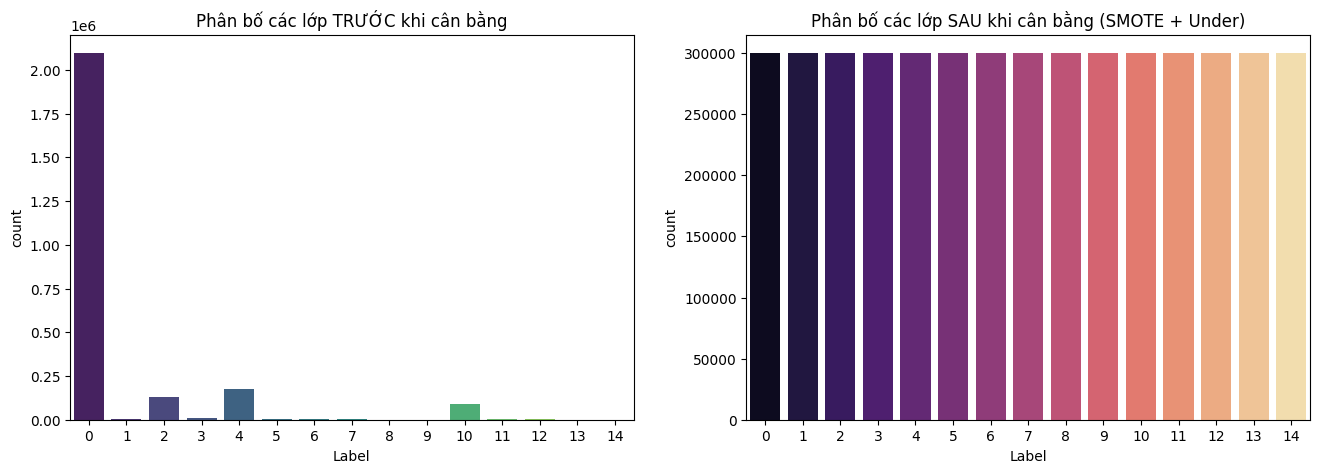

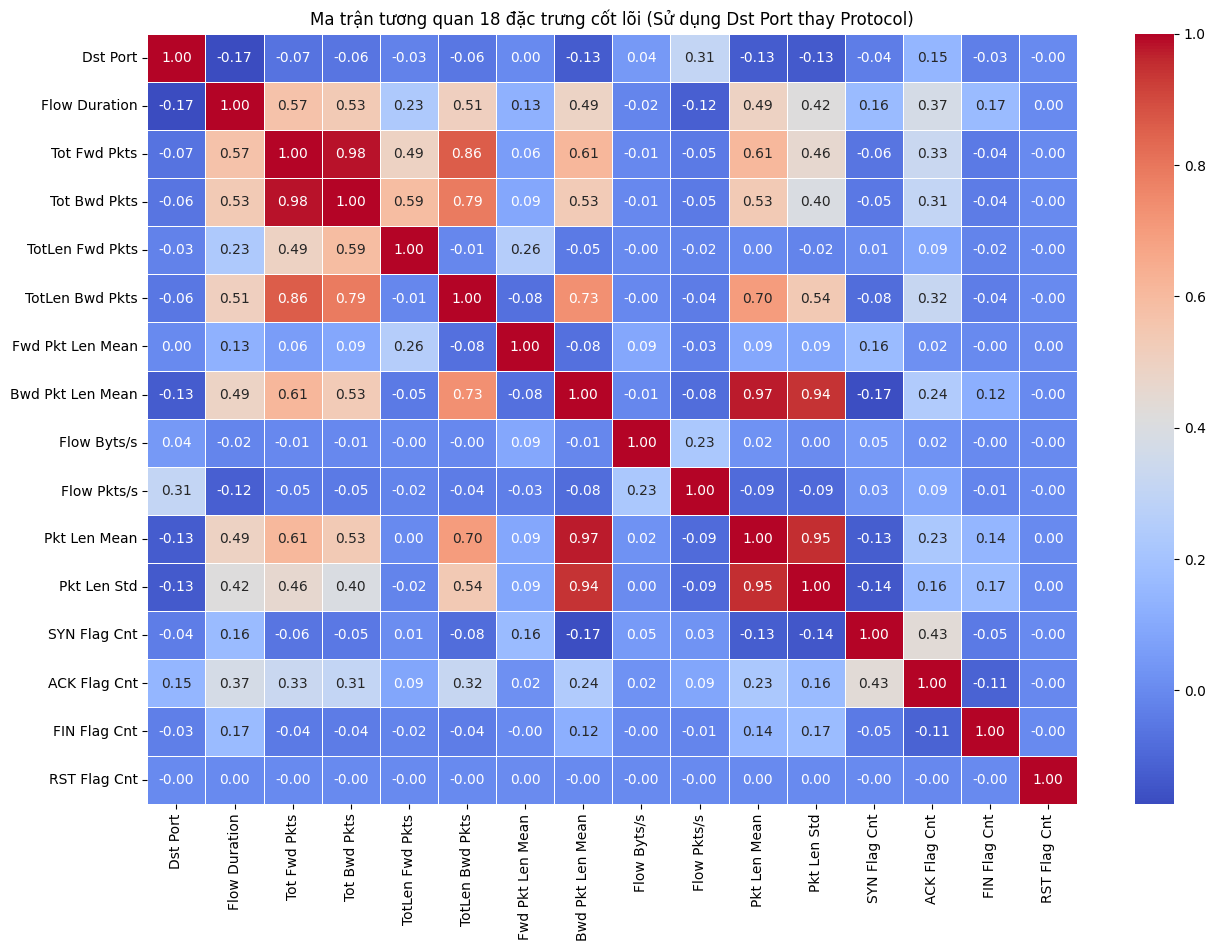

In [6]:
# 1. Vẽ Bar Chart so sánh
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(x=y, ax=axes[0], palette='viridis')
axes[0].set_title('Phân bố các lớp TRƯỚC khi cân bằng')
sns.countplot(x=y_res, ax=axes[1], palette='magma')
axes[1].set_title('Phân bố các lớp SAU khi cân bằng (SMOTE + Under)')
plt.show()

# 2. Vẽ Heatmap đủ 18 đặc trưng
# Ánh xạ tên cột từ file CSV sang tên chuẩn của Lab
column_mapping = {
    'Destination Port': 'Dst Port', # Dùng cổng đích thay cho Protocol 
    'Total Fwd Packets': 'Tot Fwd Pkts', 
    'Total Backward Packets': 'Tot Bwd Pkts',
    'Total Length of Fwd Packets': 'TotLen Fwd Pkts', 
    'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
    'Fwd Packet Length Mean': 'Fwd Pkt Len Mean', 
    'Bwd Packet Length Mean': 'Bwd Pkt Len Mean',
    'Flow Bytes/s': 'Flow Byts/s', 
    'Flow Packets/s': 'Flow Pkts/s',
    'Packet Length Mean': 'Pkt Len Mean', 
    'Packet Length Std': 'Pkt Len Std',
    'FIN Flag Count': 'FIN Flag Cnt', 
    'SYN Flag Count': 'SYN Flag Cnt',
    'RST Flag Count': 'RST Flag Cnt', 
    'PSH Flag Count': 'PSH Flag Cnt',
    'ACK Flag Count': 'ACK Flag Cnt', 
    'URG Flag Count': 'URG Flag Cnt'
}

X_res_df = pd.DataFrame(X_res, columns=X.columns)
X_res_df.rename(columns=column_mapping, inplace=True)

# Danh sách 18 đặc trưng (Đã thay Protocol bằng Dst Port)
SELECTED_FEATURES = [
    'Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Count', 'URG Flag Count'
]

# Lọc các cột thực sự tồn tại sau khi rename
existing = [c for c in SELECTED_FEATURES if c in X_res_df.columns]

plt.figure(figsize=(15, 10))
sns.heatmap(X_res_df[existing].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan 18 đặc trưng cốt lõi (Sử dụng Dst Port thay Protocol)')
plt.show()

In [7]:
joblib.dump(X_res, '../data/X_final.pkl')
joblib.dump(y_res, '../data/y_final.pkl')
print("Đã lưu dữ liệu X_final.pkl và y_final.pkl thành công!")

Đã lưu dữ liệu X_final.pkl và y_final.pkl thành công!
